In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
reviews_data = pd.read_csv(
    '/content/Reviews.csv',
    engine="python",
    quotechar='"',
    escapechar='\\',
    on_bad_lines="skip",
    header=0
)

print(reviews_data.shape)
reviews_data.head()

(86819, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
reviews_data.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [5]:
reviews_data.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,6
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,2
Text,0


In [6]:
reviews_data['Sentiment']= reviews_data.apply(lambda x: 'positive' if x['Score']>=3 else 'negative',axis=1)
reviews_data

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,positive
...,...,...,...,...,...,...,...,...,...,...,...
86814,86823,B0006SKCVI,A1Q8QT6GOH6SEX,Lakegirl,2,2,4,1320710400,Yummy!,Received this about a week ago and I have alre...,positive
86815,86824,B0006SKCVI,A1RQ1JWL02IBWK,"Jan B. Strickland ""Genealogy addict""",1,1,5,1334275200,Chili Garlic Sauce,This is a similiar product to one we used to p...,positive
86816,86825,B0006SKCVI,A384P22KDXM7RI,"G. E. Gonderinger ""Gondo""",1,1,5,1329177600,Spicy with great flavor.,"This will not ""burn out"" your mouth. It is spi...",positive
86817,86826,B0006SKCVI,A1TMB0S4TLX4JZ,Dan G.,1,1,5,1328054400,My new favorite go to hot sauce!,I purchased this at my local grocery store. I...,positive


In [7]:
reviews_data['Text']= reviews_data['Text'].str.lower()
reviews_data

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,i have bought several of the vitality canned d...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled as jumbo salted peanut...,negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",this is a confection that has been around a fe...,positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,if you are looking for the secret ingredient i...,negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,great taffy at a great price. there was a wid...,positive
...,...,...,...,...,...,...,...,...,...,...,...
86814,86823,B0006SKCVI,A1Q8QT6GOH6SEX,Lakegirl,2,2,4,1320710400,Yummy!,received this about a week ago and i have alre...,positive
86815,86824,B0006SKCVI,A1RQ1JWL02IBWK,"Jan B. Strickland ""Genealogy addict""",1,1,5,1334275200,Chili Garlic Sauce,this is a similiar product to one we used to p...,positive
86816,86825,B0006SKCVI,A384P22KDXM7RI,"G. E. Gonderinger ""Gondo""",1,1,5,1329177600,Spicy with great flavor.,"this will not ""burn out"" your mouth. it is spi...",positive
86817,86826,B0006SKCVI,A1TMB0S4TLX4JZ,Dan G.,1,1,5,1328054400,My new favorite go to hot sauce!,i purchased this at my local grocery store. i...,positive


In [8]:
import string

In [9]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [10]:
import re
sample_text = "if you are looking for the secret ingredient in robitussin i believe i have found it.  i got this in addition to the root beer extract i ordered (which was good) and made some cherry soda.  the flavor is very medicinal."

cleaned_text = re.sub(r'[^a-zA-Z\s]', '', sample_text)

print(cleaned_text)

if you are looking for the secret ingredient in robitussin i believe i have found it  i got this in addition to the root beer extract i ordered which was good and made some cherry soda  the flavor is very medicinal


In [11]:
reviews_data['Text'] = reviews_data['Text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
reviews_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,i have bought several of the vitality canned d...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled as jumbo salted peanut...,negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",this is a confection that has been around a fe...,positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,if you are looking for the secret ingredient i...,negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,great taffy at a great price there was a wide...,positive


In [12]:
import nltk

In [13]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [14]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')


reviews_data['Text'] = reviews_data['Text'].apply(lambda x: word_tokenize(x))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [15]:
print(reviews_data['Text'])

0        [i, have, bought, several, of, the, vitality, ...
1        [product, arrived, labeled, as, jumbo, salted,...
2        [this, is, a, confection, that, has, been, aro...
3        [if, you, are, looking, for, the, secret, ingr...
4        [great, taffy, at, a, great, price, there, was...
                               ...                        
86814    [received, this, about, a, week, ago, and, i, ...
86815    [this, is, a, similiar, product, to, one, we, ...
86816    [this, will, not, burn, out, your, mouth, it, ...
86817    [i, purchased, this, at, my, local, grocery, s...
86818    [the, first, time, i, tried, this, sauce, was,...
Name: Text, Length: 86819, dtype: object


In [16]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [17]:
stop_words = set(stopwords.words('english'))

reviews_data['Text'] = reviews_data['Text'].apply(lambda tokens: [word for word in tokens if word.lower() not in stop_words])

In [18]:
print(reviews_data['Text'][0])

['bought', 'several', 'vitality', 'canned', 'dog', 'food', 'products', 'found', 'good', 'quality', 'product', 'looks', 'like', 'stew', 'processed', 'meat', 'smells', 'better', 'labrador', 'finicky', 'appreciates', 'product', 'better']


In [19]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [20]:
lemmatizer = WordNetLemmatizer()


reviews_data['Text'] = reviews_data['Text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

In [21]:
reviews_data['Text'] = reviews_data['Text'].apply(lambda tokens: ' '.join(tokens))

In [22]:
from sklearn.model_selection import train_test_split


X = reviews_data['Text']


y = reviews_data['Sentiment']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(max_features=5000)


X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [24]:
y_train.value_counts()

,count
Sentiment,
positive,59088
negative,10367


### Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


model = LogisticRegression(tol=1e-6, C=1.0,
                           class_weight='balanced', random_state=None, solver='liblinear',
                           max_iter=1000)#multi_class='ovr'


model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear',
                   tol=1e-06)

In [26]:
y_pred = model.predict(X_test_tfidf)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8670237272517853

Classification Report:
               precision    recall  f1-score   support

    negative       0.53      0.85      0.66      2592
    positive       0.97      0.87      0.92     14772

    accuracy                           0.87     17364
   macro avg       0.75      0.86      0.79     17364
weighted avg       0.91      0.87      0.88     17364


Confusion Matrix:
 [[ 2195   397]
 [ 1912 12860]]


### Perceptron

In [27]:
from sklearn.linear_model import Perceptron
percep = Perceptron(tol=1e-4, random_state=43)
percep.fit(X_train_tfidf, y_train)

Perceptron(random_state=43, tol=0.0001)

In [28]:
percep_pred = percep.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, percep_pred))

Accuracy: 0.8860285648468095


### Linear Regression

In [29]:
from sklearn.preprocessing import LabelEncoder

In [30]:
le = LabelEncoder()

# Fit and transform
y_train_encoded = le.fit_transform(y_train)

In [32]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train_tfidf, y_train_encoded)
reg.score(X_train_tfidf, y_train_encoded)

0.4824293824689134

### Naive_bayes

In [33]:
from sklearn.naive_bayes import CategoricalNB
clf_nb= CategoricalNB()
arr1= X_train_tfidf.toarray()
clf_nb.fit(arr1, y_train)

CategoricalNB()

In [34]:
pred = clf_nb.predict(X_test_tfidf.toarray())
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8507256392536282


In [36]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation & special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Join back into string
    return ' '.join(tokens)

In [37]:
new_review = ["I absolutely loved this product, it was amazing!"]

# Preprocess review
processed_review = [preprocess_text(new_review[0])]

# Vectorize using fitted TF-IDF
new_review_tfidf = tfidf.transform(processed_review)

# Predict sentiment
prediction = model.predict(new_review_tfidf)
print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


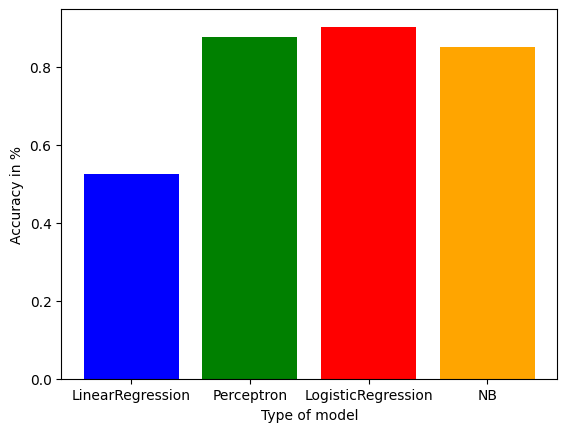

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
l=[0.5258148714693871,0.8759672280382339,0.9024806554392353,0.850022758306782]
l1=["LinearRegression","Perceptron",'LogisticRegression','NB']
# l3=[93.93939393939394,79.41176470588235,93.93939393939394,78.8235294117647]
colors = ['blue', 'green', 'red','orange','purple']
# l2=[27.27272727272727,25,27.27272727272727,18.8]
plt.bar(l1,l,color=colors)
plt.xlabel("Type of model")
plt.ylabel("Accuracy in %")
plt.show()